# Week 1 — Exploratory Data Analysis
## 1. Environment Setup & Imports
## 2. Load Dataset
## 3. Class Imbalance Analysis
## 4. Correlation Heatmap
## 5. Sensor Distribution Plots
## 6. EDA Summary & Key Findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

print("All imports successful")

All imports successful


## 3. Class Imbalance Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../data/ai4i2020.csv')

# Print shape
print("Dataset Shape:", df.shape)

# Print first 5 rows
print(df.head())

Dataset Shape: (10000, 14)
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    

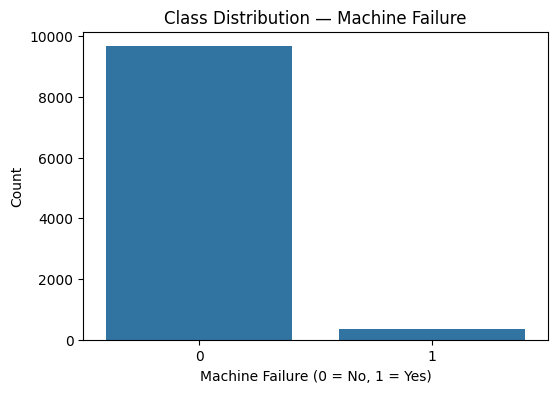

Class Counts:
Machine failure
0    9661
1     339
Name: count, dtype: int64

No Failure: 96.61%
Failure: 3.39%
Imbalance Ratio: 28.5:1


In [3]:
# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Machine failure', data=df)
plt.title('Class Distribution — Machine Failure')
plt.xlabel('Machine Failure (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Calculate class imbalance ratio
failure_counts = df['Machine failure'].value_counts()
print("Class Counts:")
print(failure_counts)

total = len(df)
failure_pct = (failure_counts[1] / total) * 100
no_failure_pct = (failure_counts[0] / total) * 100

print(f"\nNo Failure: {no_failure_pct:.2f}%")
print(f"Failure: {failure_pct:.2f}%")
print(f"Imbalance Ratio: {failure_counts[0]/failure_counts[1]:.1f}:1")

## Commentary — Class Imbalance Problem

The dataset is highly imbalanced:
- **No Failure (0):** 9661 samples — 96.61%
- **Failure (1):** 339 samples — 3.39%
- **Imbalance Ratio:** 28.5:1

This means for every 1 machine failure, there are 28 normal cases.

This is a serious problem because:
- A model that always predicts "No Failure" will get 96.61% accuracy but will NEVER detect real failures
- We must use SMOTE (Synthetic Minority Over-sampling Technique) to balance the data
- We will use Macro F1 Score instead of accuracy to measure model performance correctly

## 4. Correlation Heatmap

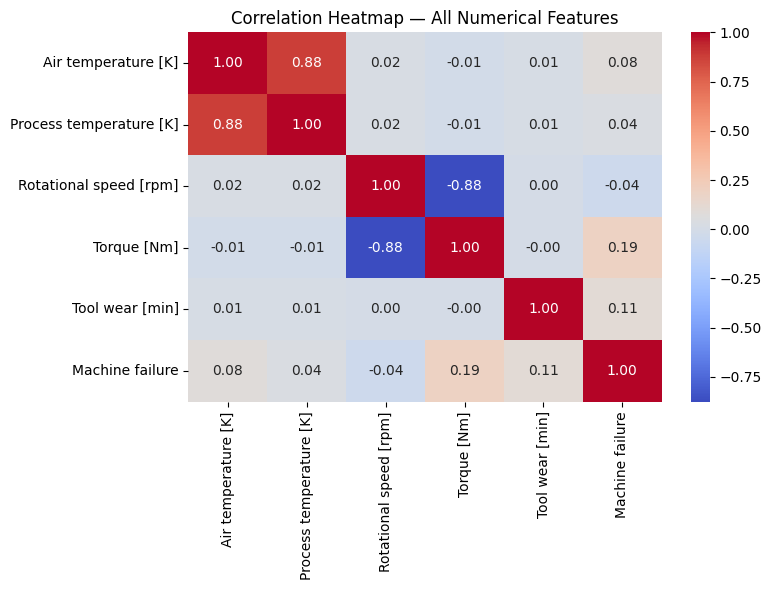

Top 3 features correlated with Machine failure:
Torque [Nm]            0.191321
Tool wear [min]        0.105448
Air temperature [K]    0.082556
Name: Machine failure, dtype: float64


In [6]:
# Select numerical columns only
numerical_cols = ['Air temperature [K]', 'Process temperature [K]', 
                  'Rotational speed [rpm]', 'Torque [Nm]', 
                  'Tool wear [min]', 'Machine failure']

# Calculate correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap — All Numerical Features')
plt.tight_layout()
plt.show()

# Top 3 features correlated with Machine failure
corr_with_failure = corr_matrix['Machine failure'].drop('Machine failure').abs().sort_values(ascending=False)
print("Top 3 features correlated with Machine failure:")
print(corr_with_failure.head(3))

## Commentary — Correlation Analysis

The correlation heatmap reveals the following insights:

**Top 3 features correlated with Machine Failure:**
1. **Torque [Nm]** — 0.19 (highest correlation)
2. **Tool wear [min]** — 0.11 (second highest)
3. **Air temperature [K]** — 0.08 (third highest)

**Key Observations:**
- Torque is the strongest predictor of machine failure
- Tool wear increases failure probability over time
- Overall correlations are low — this confirms that machine failures are complex events driven by combinations of features rather than a single sensor
- This justifies using LightGBM ensemble model which captures complex non-linear relationships